# Place-Field Recovery with a B-Spline GLM and an LGCP

A self-contained walkthrough that exercises the new
`nstat.extras.spatial` building blocks against a simulated planar
inhomogeneous Poisson process whose ground-truth log-intensity is known
analytically.  The pipeline is identical in spirit to
`examples/paper/example06_place_fields_glm_basis.py`, trimmed for
interactive use.

What we do here:

1. Simulate ~600 events on the unit square from a sum-of-Gaussian-bumps
   rate field via thinning.
2. Fit a tensor-product cubic-B-spline Poisson GLM
   (`BSplineBasis2D.from_grid` + `fit_poisson_glm`) with the log cell
   area carried as an offset.
3. Fit a basis-projected log-Gaussian Cox process (LGCP) with a Matern-5/2
   prior on the spline coefficients (`MaternPrior`, `lgcp_fit_glm`) and
   read off a posterior-mean rate map with a 90% log-normal credible band.
4. Diagnose with the edge-corrected pair correlation function
   `pair_correlation(..., edge_correction="isotropic")` and the
   global-rank envelope of Myllymaki et al. 2017.

References:

- Baddeley AJ, Moller J, Waagepetersen R (2000).  *Statistica Neerlandica*
  **54**(3):329.
- Myllymaki M, Mrkvicka T, Grabarnik P, Seijo H, Hahn U (2017).
  *Journal of the Royal Statistical Society B* **79**(2):381.
- Diggle PJ (2013).  *Statistical Analysis of Spatial and
  Spatio-Temporal Point Patterns*, 3rd ed.
- Kass RE, Eden UT, Brown EN (2014).  *Analysis of Neural Data*, ch. 19.


In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np

from nstat.extras.spatial import (
    BSplineBasis2D,
    MaternPrior,
    global_envelope,
    lgcp_fit_glm,
    pair_correlation,
)
from nstat.glm import fit_poisson_glm
from nstat.notebook_figures import (
    matlab_colorbar,
    matlab_heatmap,
    matlab_trajectory_axes,
)

rng = np.random.default_rng(20260616)
n_grid = 24


## 1. Simulate a known place field

Ground truth is a baseline log-rate of `log(400)` events per unit area
plus three additive Gaussian bumps.  We sample from this rate by Poisson
thinning under a tight upper bound estimated on a fine reference grid.


simulated n = 537 events


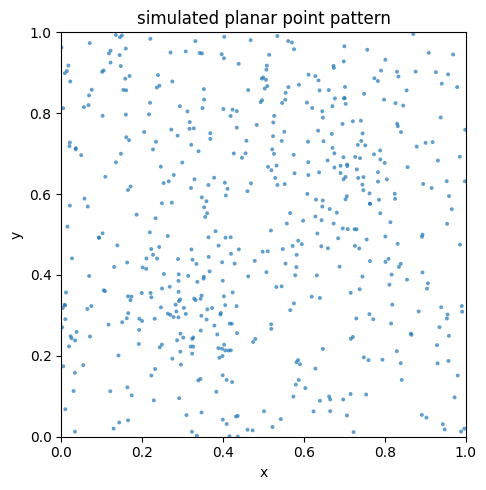

In [2]:
_BUMPS = (
    # (x0,   y0,   sx,   sy,   amp)
    (0.30, 0.30, 0.10, 0.10, 1.5),
    (0.70, 0.65, 0.08, 0.12, 1.2),
    (0.45, 0.80, 0.12, 0.07, 0.9),
)
_LOG_BASELINE = np.log(400.0)


def true_log_rate(xy: np.ndarray) -> np.ndarray:
    xy = np.atleast_2d(np.asarray(xy, dtype=float))
    x, y = xy[:, 0], xy[:, 1]
    out = np.full(x.shape, _LOG_BASELINE)
    for x0, y0, sx, sy, amp in _BUMPS:
        out = out + amp * np.exp(
            -0.5 * (((x - x0) / sx) ** 2 + ((y - y0) / sy) ** 2)
        )
    return out


def true_rate(xy: np.ndarray) -> np.ndarray:
    return np.exp(true_log_rate(xy))


def simulate_pattern(rng: np.random.Generator) -> np.ndarray:
    nref = 80
    ax = np.linspace(0.0, 1.0, nref)
    XX, YY = np.meshgrid(ax, ax, indexing="ij")
    grid = np.column_stack([XX.ravel(), YY.ravel()])
    lam_max = float(true_rate(grid).max()) * 1.05
    n_prop = rng.poisson(lam_max)
    cand = rng.uniform(size=(n_prop, 2))
    keep = rng.uniform(size=n_prop) < (true_rate(cand) / lam_max)
    return cand[keep]


pts = simulate_pattern(rng)
print(f"simulated n = {pts.shape[0]} events")

fig, ax = plt.subplots(figsize=(5.4, 5.0))
ax.scatter(pts[:, 0], pts[:, 1], s=8, color="tab:blue", edgecolor="none",
           alpha=0.7)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
matlab_trajectory_axes(ax, xlabel="x", ylabel="y")
ax.set_title("simulated planar point pattern")
fig.tight_layout()
plt.show()


## 2. Bin events and fit a B-spline GLM

We use a 24 x 24 cell grid.  The tensor-product cubic B-spline basis
(`BSplineBasis2D.from_grid`) is a partition of unity, so we fit
`include_intercept=False` and add a small L2 ridge for IRLS stability.
The log cell area enters as an `offset` so the coefficients are
identifiable in absolute log-rate units.


In [3]:
grid = np.linspace(0.0, 1.0, n_grid)
basis = BSplineBasis2D.from_grid(
    grid_x=grid, grid_y=grid, n_knots=(8, 8), degree=3
)
B = basis.design_matrix()  # (n_grid**2, 64)

edges = np.linspace(0.0, 1.0, n_grid + 1)
H, _, _ = np.histogram2d(pts[:, 0], pts[:, 1], bins=[edges, edges])
counts = H.ravel().astype(float)
cell_area = 1.0 / (n_grid * n_grid)
offset = np.full(counts.shape, np.log(cell_area))

glm = fit_poisson_glm(
    B, counts, offset=offset, include_intercept=False, l2=0.3, max_iter=300,
)
rate_basis = np.exp(B @ glm.coefficients)

axis = np.linspace(0.0, 1.0, n_grid)
XX, YY = np.meshgrid(axis, axis, indexing="ij")
grid_pts = np.column_stack([XX.ravel(), YY.ravel()])
rate_true = true_rate(grid_pts).reshape(n_grid, n_grid)
rate_basis_2d = rate_basis.reshape(n_grid, n_grid)
rmse_basis = float(np.sqrt(np.mean((rate_basis - true_rate(grid_pts)) ** 2)))
print(f"K = {B.shape[1]} basis functions; IRLS iters = {glm.n_iter}; "
      f"converged = {glm.converged}")
print(f"RMSE(truth, B-spline) = {rmse_basis:.3f}")


K = 64 basis functions; IRLS iters = 70; converged = True
RMSE(truth, B-spline) = 169.941


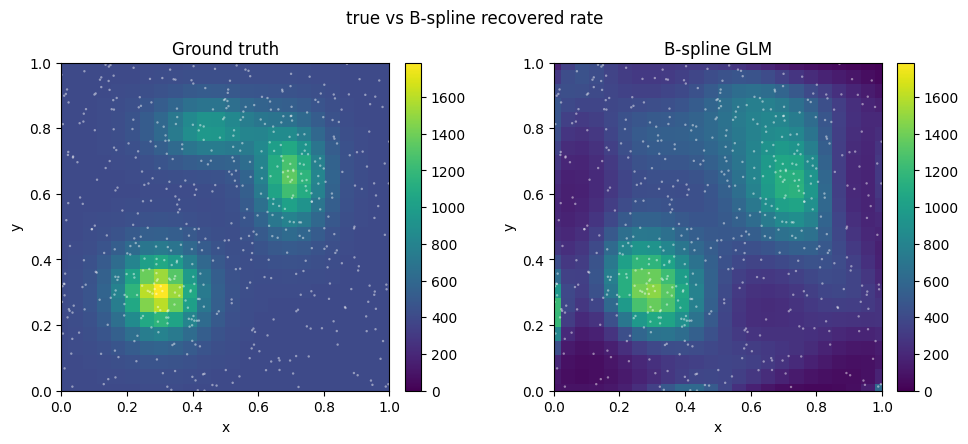

In [4]:
vmax = float(max(rate_true.max(), rate_basis_2d.max()))
fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.4))
titles = ("Ground truth", "B-spline GLM")
for ax, field, title in zip(axes, (rate_true, rate_basis_2d), titles):
    im = matlab_heatmap(ax, axis, axis, field.T, cmap="viridis",
                        shading="auto", vmin=0.0, vmax=vmax)
    ax.scatter(pts[:, 0], pts[:, 1], s=3, color="w", alpha=0.45,
               edgecolor="none")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title(title)
    matlab_trajectory_axes(ax, xlabel="x", ylabel="y")
    matlab_colorbar(im, ax)
fig.suptitle("true vs B-spline recovered rate")
fig.tight_layout()
plt.show()


## 3. LGCP comparator with a Matern prior

`lgcp_fit_glm` evaluates the spline basis at its Greville abscissae and
imposes a Matern-5/2 GP prior on the latent log-rate coefficients
(Diggle 2013).  The returned `rate_map(level=0.90)` gives the
posterior mean and a 90% log-normal credible band on the same analysis
grid.  We plot a heatmap of the posterior mean plus a horizontal slice
through the y = 0.30 bump.


LGCP IRLS iters = 6; converged = True


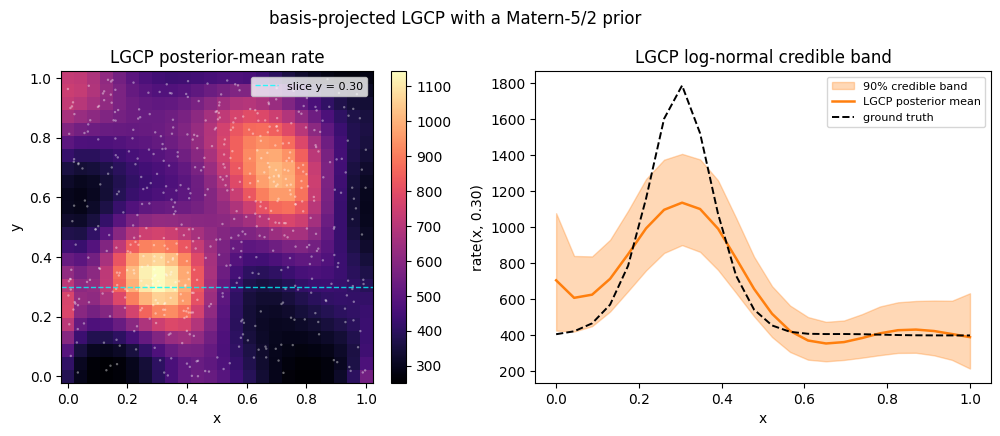

RMSE(truth, LGCP) = 132.291


In [5]:
prior = MaternPrior(nu=2.5, length_scale=0.12, marginal_var=1.0)
lgcp_res = lgcp_fit_glm(
    pts, ((0.0, 1.0), (0.0, 1.0)), basis, prior, grid=n_grid,
)
lgcp_mean, lgcp_lo, lgcp_hi = lgcp_res.rate_map(level=0.90)
print(f"LGCP IRLS iters = {lgcp_res.n_iter}; converged = {lgcp_res.converged}")

mean_2d = lgcp_mean.reshape(n_grid, n_grid)
lo_2d = lgcp_lo.reshape(n_grid, n_grid)
hi_2d = lgcp_hi.reshape(n_grid, n_grid)

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.4))
im = matlab_heatmap(axes[0], axis, axis, mean_2d.T, cmap="magma",
                    shading="auto")
axes[0].scatter(pts[:, 0], pts[:, 1], s=3, color="w", alpha=0.4,
                edgecolor="none")
axes[0].axhline(0.30, color="cyan", lw=1.0, ls="--", alpha=0.8,
                label="slice y = 0.30")
matlab_trajectory_axes(axes[0], xlabel="x", ylabel="y")
axes[0].set_title("LGCP posterior-mean rate")
axes[0].legend(loc="upper right", fontsize=8)
matlab_colorbar(im, axes[0])

j = int(np.argmin(np.abs(axis - 0.30)))
slice_grid = np.column_stack([axis, np.full_like(axis, axis[j])])
true_slice = true_rate(slice_grid)
axes[1].fill_between(axis, lo_2d[:, j], hi_2d[:, j], color="tab:orange",
                     alpha=0.30, label="90% credible band")
axes[1].plot(axis, mean_2d[:, j], color="tab:orange", lw=1.8,
             label="LGCP posterior mean")
axes[1].plot(axis, true_slice, color="k", lw=1.4, ls="--",
             label="ground truth")
axes[1].set_xlabel("x")
axes[1].set_ylabel("rate(x, 0.30)")
axes[1].set_title("LGCP log-normal credible band")
axes[1].legend(loc="upper right", fontsize=8)

fig.suptitle("basis-projected LGCP with a Matern-5/2 prior")
fig.tight_layout()
plt.show()

rmse_lgcp = float(np.sqrt(np.mean((lgcp_mean - true_rate(grid_pts)) ** 2)))
print(f"RMSE(truth, LGCP) = {rmse_lgcp:.3f}")


## 4. Second-order goodness of fit

We compute the inhomogeneous pair correlation `g(r)` with Ripley's
isotropic edge correction and benchmark it against a global-rank
envelope (49 simulations here for notebook speed; the full example
script uses 99).  Departures of the observed `g(r)` from the envelope
band, or systematic offset from the Poisson null `g(r) = 1`, indicate
residual clustering or inhibition.


envelope inside = True, p_interval = (0.8, 0.86)


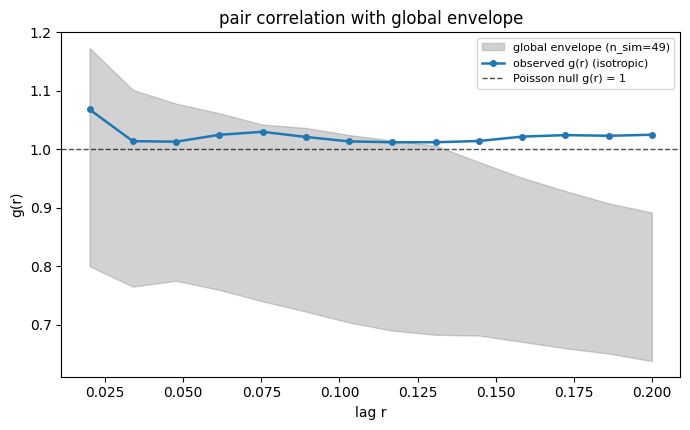

In [6]:
r_grid = np.linspace(0.02, 0.20, 14)
bw = 0.04
domain = ((0.0, 1.0), (0.0, 1.0))

lam_true_at_pts = true_rate(pts)
g = pair_correlation(
    pts, lam_true_at_pts, r_grid,
    bw=bw, domain=domain, edge_correction="isotropic",
)
env = global_envelope(
    pts, true_rate, r_grid,
    n_sim=49, domain=domain, statistic="pcf", bw=bw, rng=rng,
)
print(f"envelope inside = {env.inside}, p_interval = {env.p_interval}")

fig, ax = plt.subplots(figsize=(7.0, 4.4))
ax.fill_between(r_grid, env.lo, env.hi, color="gray", alpha=0.35,
                label=f"global envelope (n_sim={env.n_sim})")
ax.plot(r_grid, g, color="tab:blue", lw=1.8, marker="o", ms=4,
        label="observed g(r) (isotropic)")
ax.axhline(1.0, color="k", lw=1.0, ls="--", alpha=0.7,
           label="Poisson null g(r) = 1")
ax.set_xlabel("lag r")
ax.set_ylabel("g(r)")
ax.set_title("pair correlation with global envelope")
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()
plt.show()


## Recap

We saw how to:

- simulate a planar inhomogeneous Poisson process by thinning under a
  known log-rate;
- fit a tensor-product B-spline Poisson GLM with a log-area offset and a
  light L2 ridge;
- run an LGCP comparator with a Matern-5/2 prior on the spline
  coefficients and produce a log-normal credible band on the rate;
- evaluate fit with an edge-corrected pair correlation and a
  global-rank envelope.

### Bibliography

- Baddeley AJ, Moller J, Waagepetersen R (2000).  Non- and
  semi-parametric estimation of interaction in inhomogeneous point
  patterns.  *Statistica Neerlandica* **54**(3):329-350.
- Diggle PJ (2013).  *Statistical Analysis of Spatial and
  Spatio-Temporal Point Patterns*, 3rd ed.  CRC Press.
- Kass RE, Eden UT, Brown EN (2014).  *Analysis of Neural Data*,
  ch. 19.  Springer.
- Myllymaki M, Mrkvicka T, Grabarnik P, Seijo H, Hahn U (2017).
  Global envelope tests for spatial processes.  *JRSS-B*
  **79**(2):381-404.
